MARK KEITH

In [54]:
import numpy as np

height = [60,62,65,68,70,74]
weight = [140,138,150,166,190,250]

print(np.corrcoef(height,weight)[0][1])


0.9298974521408027


In [55]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.corr(numeric_only= True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [56]:
print(df.charges.corr(df.bmi))

0.19834096883362895


In [57]:
from scipy import stats
corr , p= stats.pearsonr(df.charges,df.age)
print(round(corr,4))
print(round(p,29))

0.299
5.0000000000000004e-29


In [58]:
corr_df = pd.DataFrame(columns= ['corr' ,'p'])

for col in df:
    print(col)
    if pd.api.types.is_numeric_dtype(df[col]) and col != 'charges':
        corr,p = stats.pearsonr(df.charges , df[col])
        corr_df.loc[col] = [round(corr,3),round(p,3)]

print(corr_df)

age
sex
bmi
children
smoker
region
charges
           corr      p
age       0.299  0.000
bmi       0.198  0.000
children  0.068  0.013


In [59]:
import matplotlib.pyplot as plt

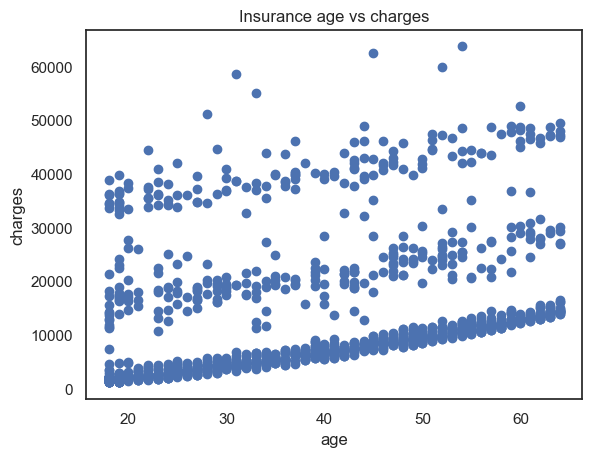

In [60]:
plt.scatter(df.age , df.charges)
plt.title('Insurance age vs charges')
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

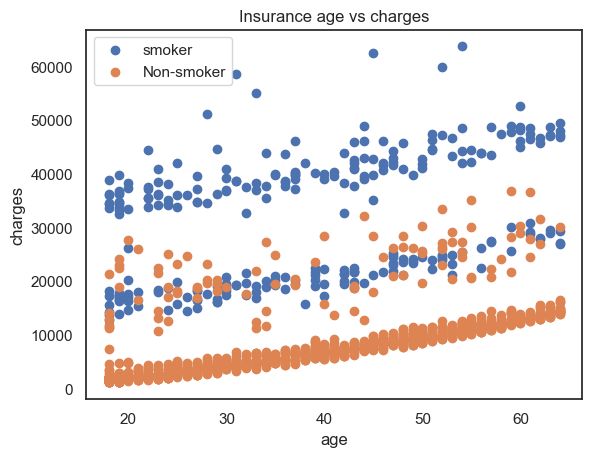

In [61]:
df_smoker = df[df['smoker'] == 'yes']
df_nonsmoker = df[df['smoker'] == 'no']

df_smoker
df_nonsmoker



plt.scatter(df_smoker.age, df_smoker.charges, label = 'smoker')
plt.scatter(df_nonsmoker.age, df_nonsmoker.charges , label = 'Non-smoker')
plt.title('Insurance age vs charges')
plt.legend()
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

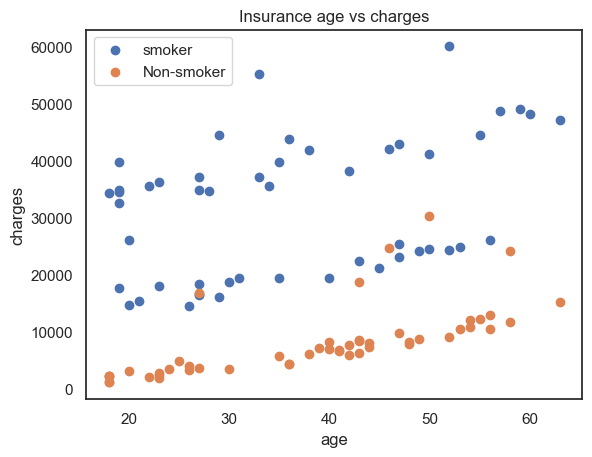

In [62]:
df_smoker_reduced = df_smoker.sample(50)
df_nonsmoker_reduced = df_nonsmoker.sample(50)

df_smoker
df_nonsmoker



plt.scatter(df_smoker_reduced.age, df_smoker_reduced.charges, label = 'smoker')
plt.scatter(df_nonsmoker_reduced.age, df_nonsmoker_reduced.charges , label = 'Non-smoker')
plt.title('Insurance age vs charges')
plt.legend()
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

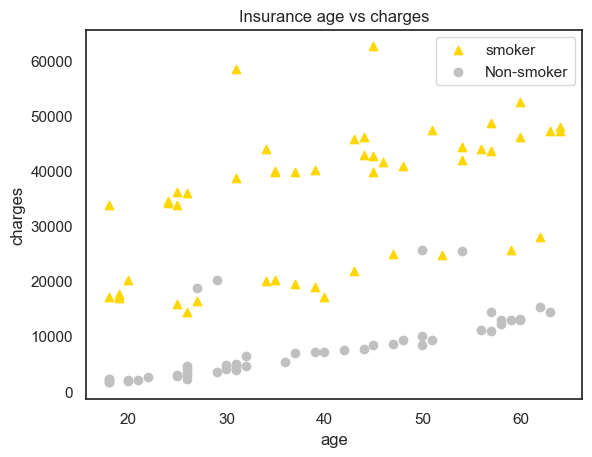

In [63]:
df_smoker_reduced = df_smoker.sample(50)
df_nonsmoker_reduced = df_nonsmoker.sample(50)

df_smoker
df_nonsmoker



plt.scatter(df_smoker_reduced.age, df_smoker_reduced.charges, label = 'smoker',color = 'gold',marker="^")
plt.scatter(df_nonsmoker_reduced.age, df_nonsmoker_reduced.charges , label = 'Non-smoker',color = 'silver',marker= 'o')
plt.title('Insurance age vs charges')
plt.legend()
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

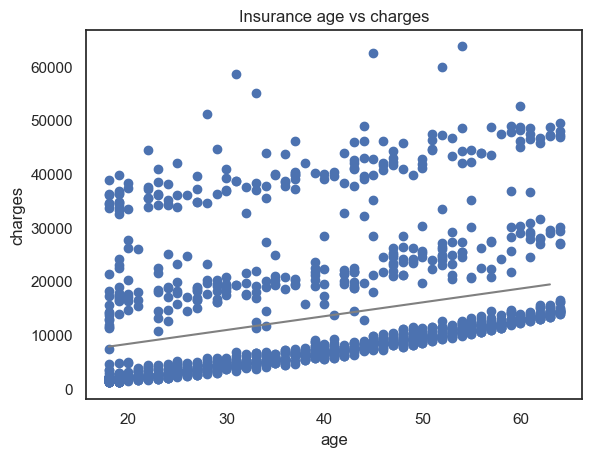

In [64]:
from scipy import stats


m,b,r,p,err= stats.linregress(df.age,df.charges)

# y = mx + b
#y = slope(x) + intercept

x = range(18, df.age.max())
y = m * x + b

plt.plot(x,y , color = 'grey')
plt.scatter(df.age , df.charges)
plt.title('Insurance age vs charges')
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

In [65]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from statsmodels.formula.api import ols

In [66]:
model = ols(formula = 'charges~age' , data = df).fit()

white_test = het_white(model.resid, model.model.exog)
breuschpagan_test = het_breuschpagan(model.resid, model.model.exog)

In [67]:
import seaborn as sns

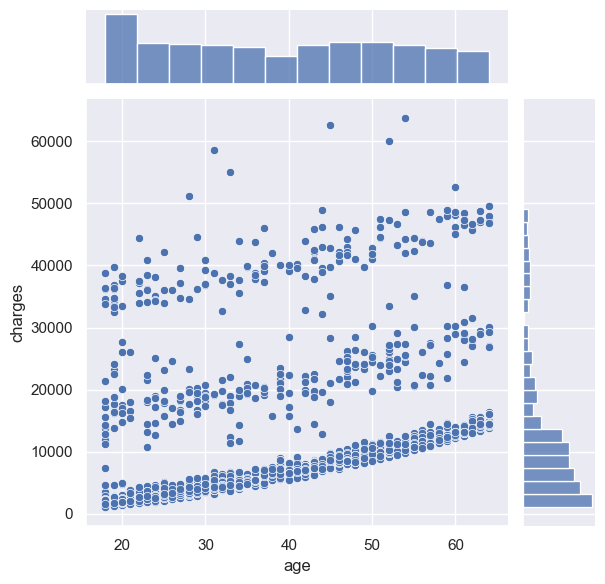

In [68]:
sns.set(color_codes=True)
sns.jointplot(x = 'age' , y = 'charges', data = df);


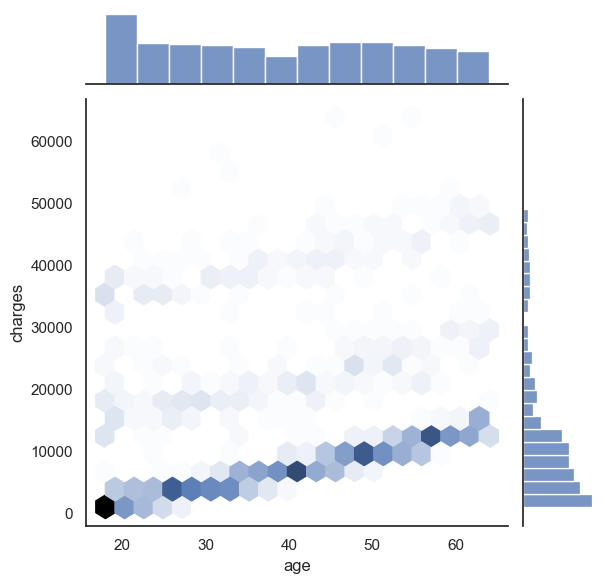

In [70]:
sns.set_style("white")
sns.jointplot(x = 'age' , y = 'charges', data = df , kind = 'hex');

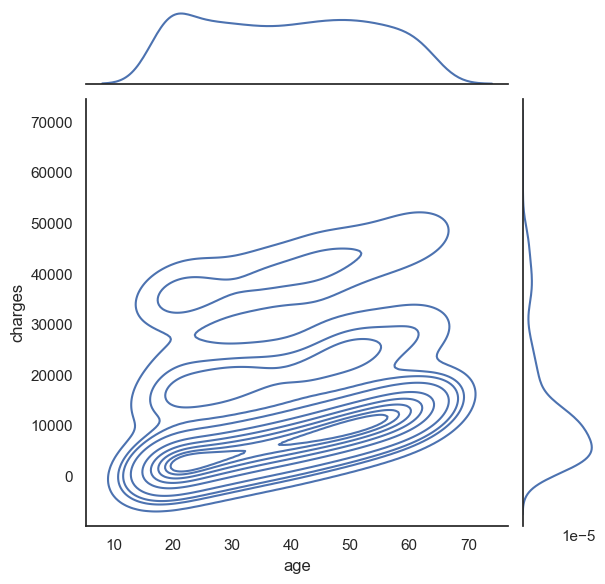

In [71]:
sns.jointplot(x = 'age' , y = 'charges', data = df , kind = 'kde');

/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_65870/1310093244.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x = df.age,y = df.charges, cmap=cmap, n_levels = 60 ,shade= True)


<Axes: xlabel='age', ylabel='charges'>

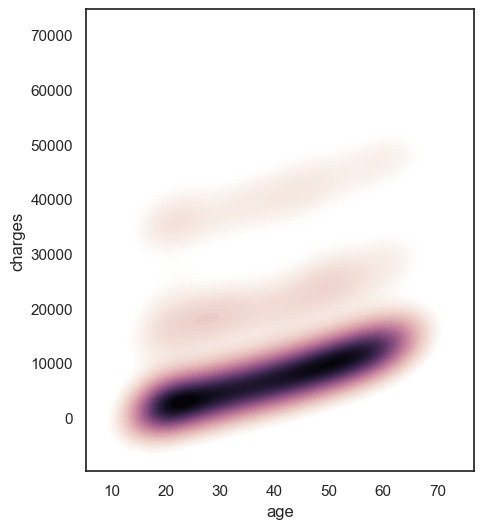

In [89]:
f, ax = plt.subplots(figsize = (5,6))
cmap = sns.cubehelix_palette(as_cmap=True , dark= 0, light=1,reverse=False)
sns.kdeplot(x = df.age,y = df.charges, cmap=cmap, n_levels = 60 ,shade= True)

In [90]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

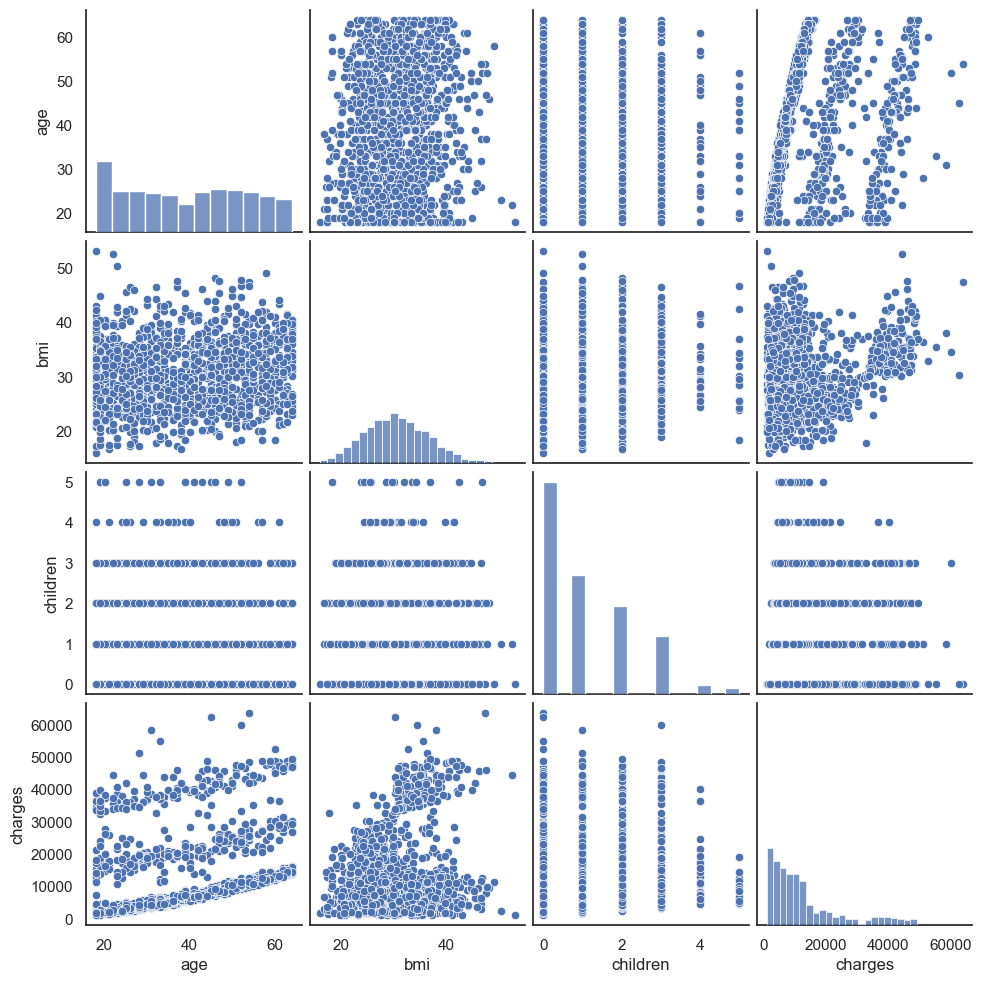

In [96]:

sns.pairplot(df)

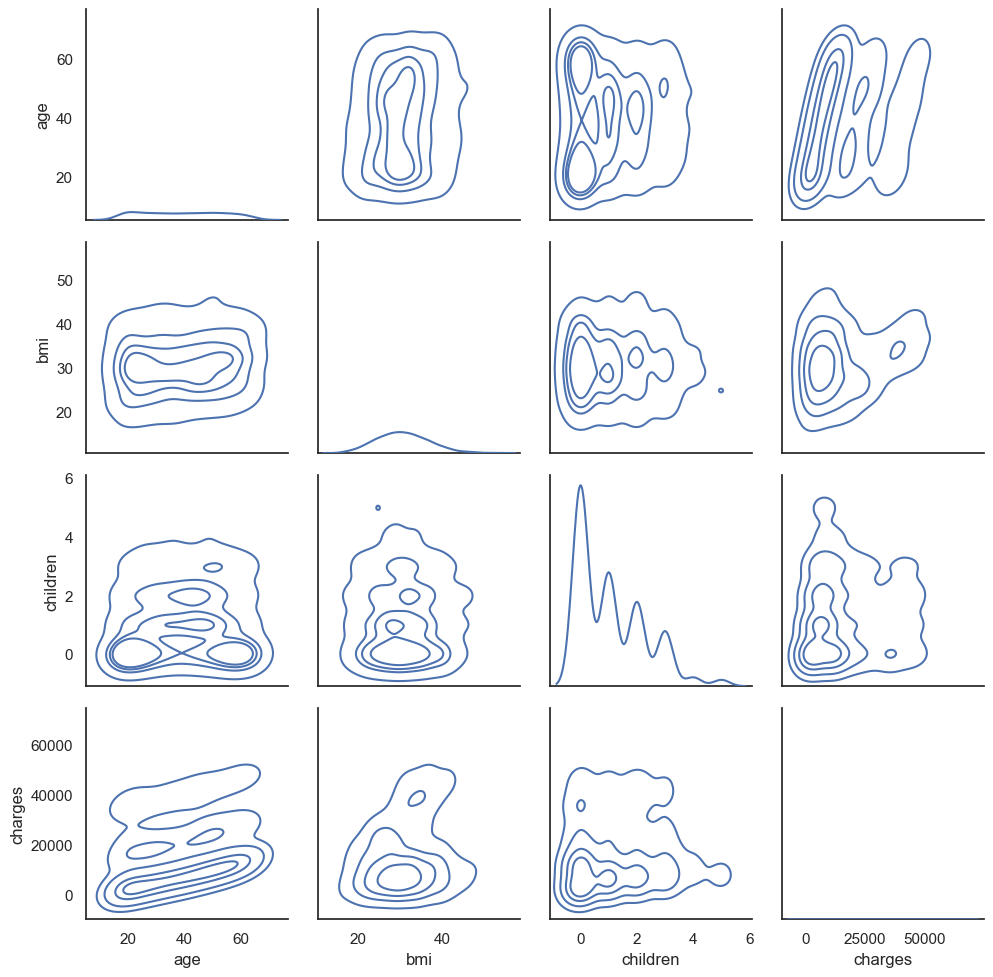

In [100]:
g = sns.PairGrid(df)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot,n_levels =5)